# Customer Analytics: RFM Segmentation, CLV & Retention

This notebook processes the Online Retail II transaction dataset into the three outputs used in the Power BI dashboards: RFM-segmented customers, CLV estimates, and a cohort retention matrix.

## 1. Load Data & Initial Data Quality Checks

Quick look at the raw dataset before any cleaning: missing values, date range, negative quantities (returns), cancelled orders, and the overall revenue distribution.

In [2]:
import pandas as pd

df = pd.read_excel("online_retail_II.xlsx")

print(df.shape)
print(df.columns)
print(df.head())
print(df.info())

(525461, 8)
Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3 2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4 2009-12-01 07:45:00   1.25      13085.0  United Kingdom  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 t

In [3]:
# Missing Values

missing = df.isnull().sum()

print("Missing Values:")
print(missing)

print("\nMissing Percentage:")
print((missing / len(df) * 100).round(2))

Missing Values:
Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

Missing Percentage:
Invoice         0.00
StockCode       0.00
Description     0.56
Quantity        0.00
InvoiceDate     0.00
Price           0.00
Customer ID    20.54
Country         0.00
dtype: float64


In [4]:
# Dataset Overview

print("Total Transactions:", len(df))

print("\nUnique Customers:")
print(df['Customer ID'].nunique())

print("\nUnique Invoices:")
print(df['Invoice'].nunique())

print("\nUnique Products:")
print(df['StockCode'].nunique())

Total Transactions: 525461

Unique Customers:
4383

Unique Invoices:
28816

Unique Products:
4632


In [5]:
# Date Range

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("First Transaction:")
print(df['InvoiceDate'].min())

print("\nLast Transaction:")
print(df['InvoiceDate'].max())

First Transaction:
2009-12-01 07:45:00

Last Transaction:
2010-12-09 20:01:00


In [6]:
# Negative Quantities

print(
    "Negative Quantity Transactions:",
    (df['Quantity'] < 0).sum()
)

Negative Quantity Transactions: 12326


In [7]:
# Cancelled Orders

cancelled = df['Invoice'].astype(str).str.startswith('C').sum()

print("Cancelled Invoices:", cancelled)

Cancelled Invoices: 10206


In [8]:
# Revenue Distribution

df['Revenue'] = df['Quantity'] * df['Price']
print(df['Revenue'].describe())

count    525461.000000
mean         18.154506
std         160.333083
min      -53594.360000
25%           3.750000
50%           9.950000
75%          17.700000
max       25111.090000
Name: Revenue, dtype: float64


## 2. Data Cleaning Pipeline

Raw transaction data contains missing customer IDs, cancelled orders (invoice numbers starting with `C`), negative quantities (returns), and invalid prices. The 8 steps below remove these before any analysis, then validate the result.

In [9]:
# -----------------------------------------------------------
# STEP 1: Create a working copy of the original dataset
# -----------------------------------------------------------
# Why?
# We never modify the original dataframe directly.
# This allows us to go back if something goes wrong.
# -----------------------------------------------------------

retail = df.copy()

print("Original Dataset Shape:")
print(retail.shape)

Original Dataset Shape:
(525461, 9)


In [10]:
# -----------------------------------------------------------
# STEP 2: Remove transactions without Customer ID
# -----------------------------------------------------------
# Why?
# RFM is customer-level analysis.
#
# If Customer ID is missing:
# - We cannot identify who made the purchase
# - We cannot calculate Recency
# - We cannot calculate Frequency
# - We cannot calculate Monetary Value
#
# Therefore these records must be excluded.
# -----------------------------------------------------------

retail = retail.dropna(subset=['Customer ID'])

print("Shape after removing missing Customer IDs:")
print(retail.shape)

Shape after removing missing Customer IDs:
(417534, 9)


In [11]:
# -----------------------------------------------------------
# STEP 3: Remove cancelled invoices
# -----------------------------------------------------------
# Why?
#
# In the Online Retail dataset, cancelled invoices begin
# with the letter 'C'.
#
# Example:
# C536379
#
# These transactions represent:
# - Order cancellations
# - Refunds
# - Reversals
#
# Since RFM measures actual purchasing behaviour,
# cancelled orders should not be included.
# -----------------------------------------------------------

retail = retail[
    ~retail['Invoice'].astype(str).str.startswith('C')
]

print("Shape after removing cancelled invoices:")
print(retail.shape)

Shape after removing cancelled invoices:
(407695, 9)


In [13]:
# -----------------------------------------------------------
# STEP 4: Remove negative quantity transactions
# -----------------------------------------------------------
# Why?
#
# Negative quantities typically indicate:
# - Product returns
# - Refund adjustments
# - Inventory corrections
#
# Example:
# Quantity = -3
#
# This is not a new purchase,
# therefore it should not influence RFM scores.
# -----------------------------------------------------------

retail = retail[
    retail['Quantity'] > 0
]

print("Shape after removing negative quantities:")
print(retail.shape)

Shape after removing negative quantities:
(407695, 9)


In [14]:
# -----------------------------------------------------------
# STEP 5: Remove invalid pricing records
# -----------------------------------------------------------
# Why?
#
# A product should not have:
# - Price = 0
# - Negative Price
#
# Such records usually represent:
# - Data entry errors
# - Promotional placeholders
# - Internal system adjustments
#
# These records do not contribute meaningful revenue.
# -----------------------------------------------------------

retail = retail[
    retail['Price'] > 0
]

print("Shape after removing invalid prices:")
print(retail.shape)

Shape after removing invalid prices:
(407664, 9)


In [15]:
# -----------------------------------------------------------
# STEP 6: Calculate transaction revenue
# -----------------------------------------------------------
# Formula:
#
# Revenue = Quantity × Unit Price
#
# Why?
#
# Revenue is the foundation of:
# - Monetary Value (M in RFM)
# - Customer Lifetime Value (CLV)
# - Revenue contribution analysis
#
# Example:
# Quantity = 5
# Price = £10
#
# Revenue = £50
# -----------------------------------------------------------

retail['Revenue'] = retail['Quantity'] * retail['Price']

print("Revenue column created successfully.")

Revenue column created successfully.


In [16]:
# -----------------------------------------------------------
# STEP 7: Validate cleaned dataset
# -----------------------------------------------------------
# Purpose:
#
# Verify dataset quality after cleaning.
#
# Metrics checked:
# - Total transactions
# - Total customers
# - Total invoices
# - Total revenue
#
# These values will become baseline business metrics.
# -----------------------------------------------------------

print("=" * 50)
print("CLEAN DATASET SUMMARY")
print("=" * 50)

print(f"Total Transactions: {len(retail):,}")

print(f"Unique Customers: {retail['Customer ID'].nunique():,}")

print(f"Unique Invoices: {retail['Invoice'].nunique():,}")

print(f"Total Revenue: £{retail['Revenue'].sum():,.2f}")

print("=" * 50)

CLEAN DATASET SUMMARY
Total Transactions: 407,664
Unique Customers: 4,312
Unique Invoices: 19,213
Total Revenue: £8,832,003.27


In [17]:
# -----------------------------------------------------------
# STEP 8: Final quality checks
# -----------------------------------------------------------
# Ensure no problematic records remain.
# -----------------------------------------------------------

print("Remaining Missing Customer IDs:")
print(retail['Customer ID'].isnull().sum())

print("\nRemaining Negative Quantities:")
print((retail['Quantity'] < 0).sum())

print("\nRemaining Invalid Prices:")
print((retail['Price'] <= 0).sum())

print("\nRemaining Cancelled Invoices:")
print(
    retail['Invoice']
    .astype(str)
    .str.startswith('C')
    .sum()
)

Remaining Missing Customer IDs:
0

Remaining Negative Quantities:
0

Remaining Invalid Prices:
0

Remaining Cancelled Invoices:
0


## 3. Exploratory Customer Analysis

Before segmenting customers, this section checks overall revenue trends, country-level performance, and the spread of customer spending to sanity-check the cleaned data.

In [ ]:
# Exploratory Customer Analysis

After cleaning the transaction data, we perform exploratory analysis to understand:

- Overall business performance
- Customer purchasing behaviour
- Revenue distribution
- Geographic contribution

These insights provide context for the RFM segmentation model.

In [18]:
# -----------------------------------------------------------
# BUSINESS OVERVIEW
# -----------------------------------------------------------
# High-level KPIs describing overall performance.
# These metrics are commonly shown in executive dashboards.
# -----------------------------------------------------------

total_revenue = retail['Revenue'].sum()

total_customers = retail['Customer ID'].nunique()

total_orders = retail['Invoice'].nunique()

avg_order_value = total_revenue / total_orders

revenue_per_customer = total_revenue / total_customers

print("=" * 60)
print("BUSINESS OVERVIEW")
print("=" * 60)

print(f"Total Revenue: £{total_revenue:,.2f}")

print(f"Total Customers: {total_customers:,}")

print(f"Total Orders: {total_orders:,}")

print(f"Average Order Value (AOV): £{avg_order_value:,.2f}")

print(f"Average Revenue per Customer: £{revenue_per_customer:,.2f}")

print("=" * 60)

BUSINESS OVERVIEW
Total Revenue: £8,832,003.27
Total Customers: 4,312
Total Orders: 19,213
Average Order Value (AOV): £459.69
Average Revenue per Customer: £2,048.24


In [ ]:
## Key Metrics Explained

**Total Revenue**
Represents total sales generated during the analysis period.

**Average Order Value (AOV)**
Measures how much customers spend per transaction.

**Revenue per Customer**
Provides an initial estimate of customer value before segmentation.

In [19]:
# -----------------------------------------------------------
# MONTHLY REVENUE TREND
# -----------------------------------------------------------
# Objective:
# Understand how sales changed over time.
# -----------------------------------------------------------

monthly_revenue = (
    retail
    .set_index('InvoiceDate')
    .resample('ME')['Revenue']
    .sum()
)

monthly_revenue.head()

InvoiceDate
2009-12-31    686654.160
2010-01-31    557319.062
2010-02-28    506371.066
2010-03-31    699608.991
2010-04-30    594609.192
Freq: ME, Name: Revenue, dtype: float64

In [20]:
# -----------------------------------------------------------
# COUNTRY PERFORMANCE
# -----------------------------------------------------------
# Identify markets generating the highest revenue.
# -----------------------------------------------------------

country_revenue = (
    retail
    .groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

country_revenue.head(10)

Country
United Kingdom    7414755.963
EIRE               356085.210
Netherlands        268786.000
Germany            202395.321
France             146215.420
Sweden              53171.390
Denmark             50906.850
Spain               47601.420
Switzerland         43921.390
Australia           31446.800
Name: Revenue, dtype: float64

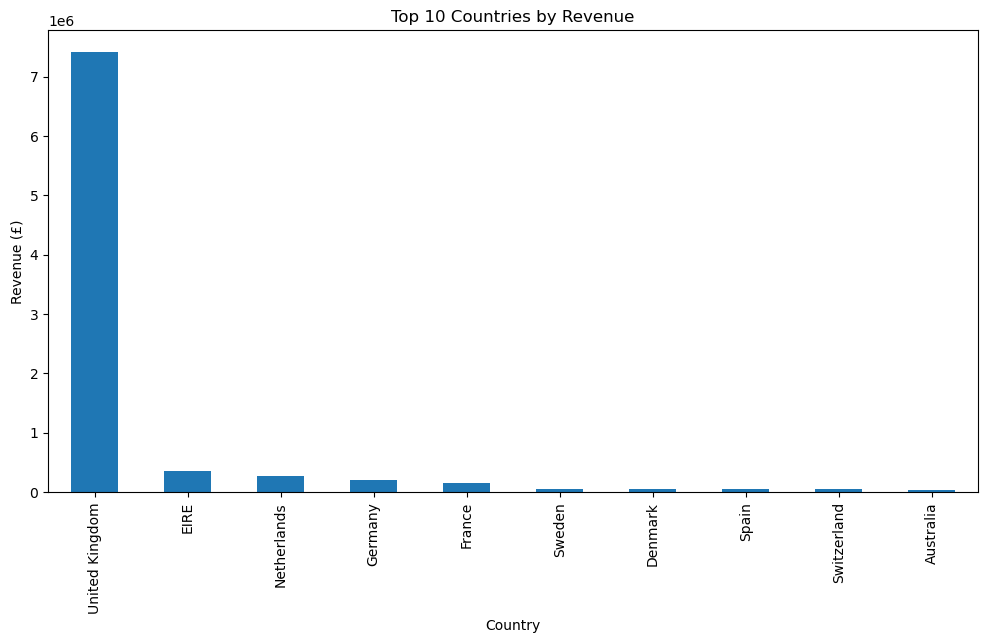

In [23]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))

country_revenue.head(10).plot(kind='bar')

plt.title("Top 10 Countries by Revenue")
plt.ylabel("Revenue (£)")
plt.xlabel("Country")

plt.show()

In [21]:
# -----------------------------------------------------------
# CUSTOMER SPENDING ANALYSIS
# -----------------------------------------------------------
# Calculate revenue generated by each customer.
# -----------------------------------------------------------

customer_revenue = (
    retail
    .groupby('Customer ID')['Revenue']
    .sum()
)

customer_revenue.describe()

count      4312.000000
mean       2048.238236
std        8914.481280
min           2.950000
25%         307.987500
50%         706.020000
75%        1723.142500
max      349164.350000
Name: Revenue, dtype: float64

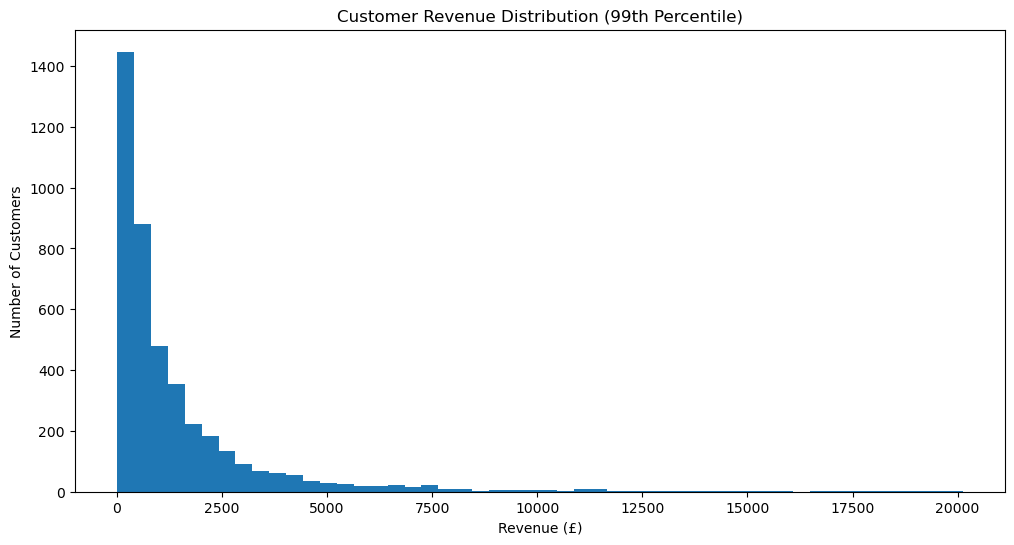

In [38]:
cutoff = customer_revenue.quantile(0.99)

filtered = customer_revenue[
    customer_revenue <= cutoff
]

plt.figure(figsize=(12,6))

plt.hist(filtered, bins=50)

plt.title("Customer Revenue Distribution (99th Percentile)")
plt.xlabel("Revenue (£)")
plt.ylabel("Number of Customers")

plt.show()

In [22]:
customer_revenue.describe(percentiles=[0.25,0.5,0.75,0.9,0.95,0.99])

count      4312.000000
mean       2048.238236
std        8914.481280
min           2.950000
25%         307.987500
50%         706.020000
75%        1723.142500
90%        3800.225000
95%        6237.603500
99%       20137.237500
max      349164.350000
Name: Revenue, dtype: float64

In [32]:
# -----------------------------------------------------------
# HIGHEST VALUE CUSTOMERS
# -----------------------------------------------------------
# Identify customers generating the most revenue.
# -----------------------------------------------------------

top_customers = (
    retail
    .groupby('Customer ID')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_customers)

Customer ID
18102.0    349164.35
14646.0    248396.50
14156.0    196566.74
14911.0    152147.57
13694.0    131443.19
17511.0     84541.17
15061.0     83284.38
16684.0     80489.21
16754.0     65500.07
17949.0     60117.60
Name: Revenue, dtype: float64


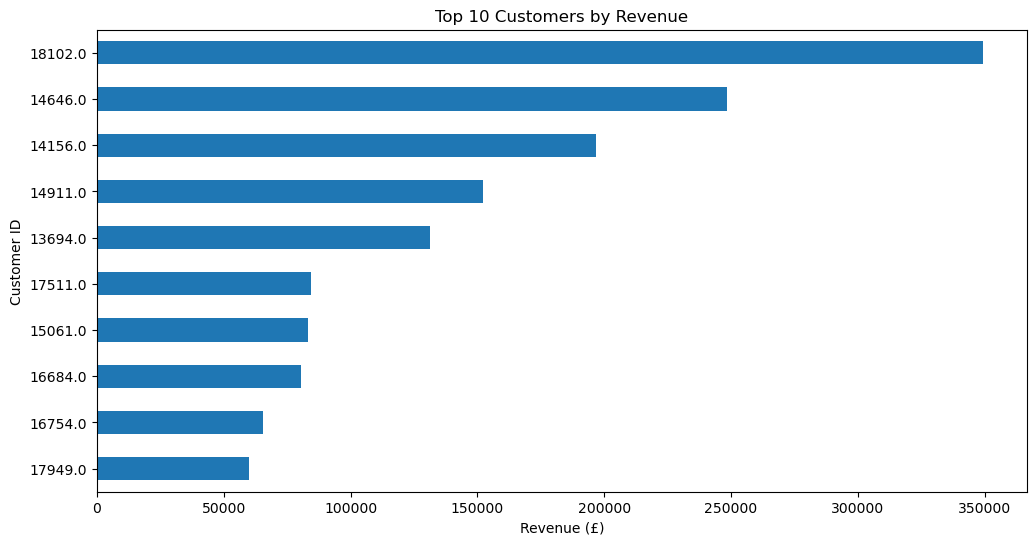

In [33]:
plt.figure(figsize=(12,6))

top_customers.sort_values().plot(kind='barh')

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue (£)")

plt.show()

In [23]:
print(retail.columns)

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'Revenue'],
      dtype='object')


## 4. RFM Score Calculation & Segmentation

Each customer is scored 1–5 on Recency, Frequency, and Monetary value using quintiles, then mapped to one of 5 business segments (Champions, Loyal, At-Risk, New, Potential Loyalists) via `segment_customer()`.

In [24]:
# -----------------------------------------------------------
# STEP 5.1: CREATE RFM BASE TABLE
# -----------------------------------------------------------
# We now convert transaction-level data into customer-level data.
# Each row = one customer
# -----------------------------------------------------------

import pandas as pd
from datetime import timedelta

# Reference date = last transaction + 1 day
reference_date = retail['InvoiceDate'].max() + timedelta(days=1)

print("Reference Date:", reference_date)

# Create RFM table
rfm = retail.groupby('Customer ID').agg({

    # Recency: days since last purchase
    'InvoiceDate': lambda x: (reference_date - x.max()).days,

    # Frequency: number of transactions
    'Invoice': 'nunique',

    # Monetary: total spend
    'Revenue': 'sum'

}).reset_index()

# Rename columns properly
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

rfm.head()

Reference Date: 2010-12-10 20:01:00


,CustomerID,Recency,Frequency,Monetary
0,12346.0,165,11,372.86
1,12347.0,3,2,1323.32
2,12348.0,74,1,222.16
3,12349.0,43,3,2671.14
4,12351.0,11,1,300.93


In [41]:
# -----------------------------------------------------------
# STEP 5.2: BASIC RFM VALIDATION
# -----------------------------------------------------------

print("RFM Shape:", rfm.shape)

print("\nMissing Values:")
print(rfm.isnull().sum())

print("\nRFM Summary:")
print(rfm.describe())

print("\nSample Customers:")
print(rfm.head(10))

RFM Shape: (4312, 4)

Missing Values:
CustomerID    0
Recency       0
Frequency     0
Monetary      0
dtype: int64

RFM Summary:
         CustomerID      Recency    Frequency       Monetary
count   4312.000000  4312.000000  4312.000000    4312.000000
mean   15349.290353    91.171846     4.455705    2048.238236
std     1701.200176    96.860633     8.170213    8914.481280
min    12346.000000     1.000000     1.000000       2.950000
25%    13882.500000    18.000000     1.000000     307.987500
50%    15350.500000    53.000000     2.000000     706.020000
75%    16834.250000   136.000000     5.000000    1723.142500
max    18287.000000   374.000000   205.000000  349164.350000

Sample Customers:
   CustomerID  Recency  Frequency  Monetary
0     12346.0      165         11    372.86
1     12347.0        3          2   1323.32
2     12348.0       74          1    222.16
3     12349.0       43          3   2671.14
4     12351.0       11          1    300.93
5     12352.0       11          2    34

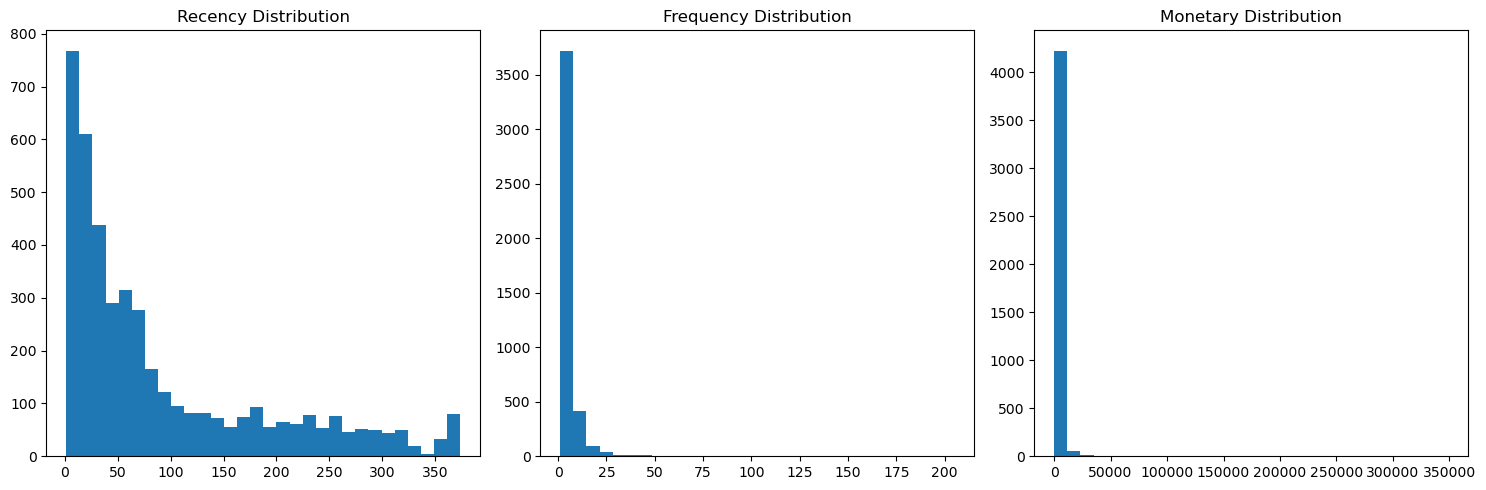

In [25]:
import matplotlib.pyplot as plt

# -----------------------------------------------------------
# STEP 5.3: DISTRIBUTION CHECK
# -----------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(15,5))

# Recency distribution
axes[0].hist(rfm['Recency'], bins=30)
axes[0].set_title("Recency Distribution")

# Frequency distribution
axes[1].hist(rfm['Frequency'], bins=30)
axes[1].set_title("Frequency Distribution")

# Monetary distribution
axes[2].hist(rfm['Monetary'], bins=30)
axes[2].set_title("Monetary Distribution")

plt.tight_layout()
plt.show()

In [26]:
# -----------------------------------------------------------
# STEP 6.1: CREATE RFM SCORES (1–5 SCALE)
# -----------------------------------------------------------
# We convert raw values into relative rankings
# 5 = best customer, 1 = worst customer
# -----------------------------------------------------------

import pandas as pd

# RECENCY SCORE
# LOWER recency = better customer (recent buyer)
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    q=5,
    labels=[5,4,3,2,1]
).astype(int)

# FREQUENCY SCORE
# HIGH frequency = better customer
rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    q=5,
    labels=[1,2,3,4,5]
).astype(int)

# MONETARY SCORE
# HIGH monetary = better customer
rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    q=5,
    labels=[1,2,3,4,5]
).astype(int)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,12346.0,165,11,372.86,2,5,2
1,12347.0,3,2,1323.32,5,2,4
2,12348.0,74,1,222.16,2,1,1
3,12349.0,43,3,2671.14,3,3,5
4,12351.0,11,1,300.93,5,1,2


In [27]:
# -----------------------------------------------------------
# STEP 6.2: CREATE FINAL RFM CODE
# -----------------------------------------------------------

rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

rfm[['CustomerID','Recency','Frequency','Monetary',
     'R_Score','F_Score','M_Score','RFM_Score']].head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346.0,165,11,372.86,2,5,2,252
1,12347.0,3,2,1323.32,5,2,4,524
2,12348.0,74,1,222.16,2,1,1,211
3,12349.0,43,3,2671.14,3,3,5,335
4,12351.0,11,1,300.93,5,1,2,512


In [28]:
# -----------------------------------------------------------
# STEP 6.3: SCORE DISTRIBUTION CHECK
# -----------------------------------------------------------

print("R Score Distribution:")
print(rfm['R_Score'].value_counts().sort_index())

print("\nF Score Distribution:")
print(rfm['F_Score'].value_counts().sort_index())

print("\nM Score Distribution:")
print(rfm['M_Score'].value_counts().sort_index())

print("\nRFM Score Sample:")
print(rfm['RFM_Score'].value_counts().head(10))

R Score Distribution:
R_Score
1    855
2    848
3    850
4    853
5    906
Name: count, dtype: int64

F Score Distribution:
F_Score
1    863
2    862
3    862
4    862
5    863
Name: count, dtype: int64

M Score Distribution:
M_Score
1    863
2    862
3    862
4    862
5    863
Name: count, dtype: int64

RFM Score Sample:
RFM_Score
555    350
111    201
455    153
121    146
112    107
233     98
444     95
554     94
122     94
544     93
Name: count, dtype: int64


In [29]:
def segment_customer(r, f, m):

    # 1. CHAMPIONS (best customers)
    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"

    # 2. LOYAL CUSTOMERS
    elif r >= 3 and f >= 3:
        return "Loyal Customers"

    # 3. POTENTIAL LOYALISTS
    elif r >= 4 and f <= 2:
        return "Potential Loyalists"

    # 4. AT RISK
    elif r <= 2 and f >= 3:
        return "At-Risk Customers"

    # 5. NEW CUSTOMERS
    else:
        return "New Customers"

In [30]:
rfm['Segment'] = rfm.apply(
    lambda row: segment_customer(
        row['R_Score'],
        row['F_Score'],
        row['M_Score']
    ),
    axis=1
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346.0,165,11,372.86,2,5,2,252,At-Risk Customers
1,12347.0,3,2,1323.32,5,2,4,524,Potential Loyalists
2,12348.0,74,1,222.16,2,1,1,211,New Customers
3,12349.0,43,3,2671.14,3,3,5,335,Loyal Customers
4,12351.0,11,1,300.93,5,1,2,512,Potential Loyalists


In [32]:
segment_summary = rfm['Segment'].value_counts()

print(segment_summary)

# Revenue by segment
print(
    rfm.groupby('Segment')['Monetary']
    .sum()
    .sort_values(ascending=False)
)

Segment
New Customers          1358
Loyal Customers         973
Champions               926
At-Risk Customers       688
Potential Loyalists     367
Name: count, dtype: int64
Segment
Champions              5729743.397
Loyal Customers        1314097.082
At-Risk Customers      1042062.301
New Customers           561410.264
Potential Loyalists     184690.230
Name: Monetary, dtype: float64


## 5. Cohort Retention Analysis

Customers are grouped by the month of their first purchase (their "cohort"), then tracked month by month to see what percentage of each cohort is still buying.

In [33]:
import pandas as pd

retail['InvoiceDate'] = pd.to_datetime(retail['InvoiceDate'])

retail['OrderMonth'] = retail['InvoiceDate'].dt.to_period('M')

In [34]:
retail['CohortMonth'] = retail.groupby('Customer ID')['OrderMonth'].transform('min')

In [35]:
def get_cohort_index(row):
    year_diff = row['OrderMonth'].year - row['CohortMonth'].year
    month_diff = row['OrderMonth'].month - row['CohortMonth'].month

    return year_diff * 12 + month_diff + 1

retail['CohortIndex'] = retail.apply(get_cohort_index, axis=1)

In [36]:
cohort_data = retail.groupby(['CohortMonth', 'CohortIndex'])['Customer ID'].nunique().reset_index()

In [37]:
cohort_pivot = cohort_data.pivot(
    index='CohortMonth',
    columns='CohortIndex',
    values='Customer ID'
)

In [38]:
cohort_size = cohort_pivot.iloc[:,0]

retention = cohort_pivot.divide(cohort_size, axis=0)

retention.round(3)

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2009-12,1.0,0.353,0.334,0.425,0.380,0.359,0.377,0.342,0.336,0.362,0.422,0.495,0.248
2010-01,1.0,0.206,0.311,0.305,0.264,0.300,0.258,0.230,0.279,0.319,0.303,0.099,NaN
2010-02,1.0,0.238,0.225,0.291,0.246,0.201,0.193,0.286,0.254,0.275,0.072,NaN,NaN
2010-03,1.0,0.190,0.230,0.242,0.233,0.203,0.246,0.302,0.275,0.079,NaN,NaN,NaN
2010-04,1.0,0.194,0.194,0.163,0.184,0.224,0.276,0.262,0.068,NaN,NaN,NaN,NaN
2010-05,1.0,0.157,0.169,0.173,0.177,0.256,0.213,0.079,NaN,NaN,NaN,NaN,NaN
2010-06,1.0,0.174,0.189,0.204,0.230,0.285,0.067,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,1.0,0.156,0.183,0.296,0.290,0.102,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,1.0,0.204,0.296,0.321,0.117,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 6. Customer Lifetime Value (CLV) Estimation

**Formula:** `CLV = AvgOrderValue × Frequency × (CustomerAgeDays / 30)`, where `CustomerAgeDays` is the gap between a customer's first and last purchase.

**⚠️ Known limitation:** this formula returns exactly 0 for any customer whose first and last purchase fall on the same calendar day (`CustomerAgeDays = 0`), regardless of how much they spent. The next cell filters these customers out entirely (`clv[clv['CLV'] > 0]`), which removes roughly 1,500 of the ~4,300 total customers — mostly one-time buyers — from every CLV-based metric downstream.

**This is why 'Average CLV' and 'Total CLV' in the dashboard are calculated over ~2,815 customers, not the full 4,312.** Two ways to fix this: (1) use `max(CustomerAgeDays, 1)` so one-time buyers get a non-zero CLV equal to their single order value, or (2) keep the current formula but clearly label CLV metrics as 'repeat customers only, n=2,815' wherever they're reported.

In [39]:
# PREPARE DATA FOR CLV
clv = retail.groupby('Customer ID').agg({
    'Revenue': 'sum',
    'Invoice': 'nunique',
    'InvoiceDate': lambda x: (x.max() - x.min()).days
}).reset_index()

clv.columns = ['CustomerID', 'TotalRevenue', 'Frequency', 'CustomerAgeDays']

clv.head()

,CustomerID,TotalRevenue,Frequency,CustomerAgeDays
0,12346.0,372.86,11,196
1,12347.0,1323.32,2,37
2,12348.0,222.16,1,0
3,12349.0,2671.14,3,181
4,12351.0,300.93,1,0


In [ ]:
# ADD BASIC CLV LOGIC

clv['AvgOrderValue'] = clv['TotalRevenue'] / clv['Frequency']

# approximate monthly lifetime value
clv['CLV'] = clv['AvgOrderValue'] * clv['Frequency'] * (clv['CustomerAgeDays'].clip(lower=1) / 30)
clv.head()

,CustomerID,TotalRevenue,Frequency,CustomerAgeDays,AvgOrderValue,CLV
0,12346.0,372.86,11,196,33.896364,2436.018667
1,12347.0,1323.32,2,37,661.660000,1632.094667
2,12348.0,222.16,1,0,222.160000,0.000000
3,12349.0,2671.14,3,181,890.380000,16115.878000
4,12351.0,300.93,1,0,300.930000,0.000000


In [ ]:
# CLV SEGMENTS (BUSINESS VIEW)

clv_clean = clv.copy()
clv_clean['CLV_Segment'] = pd.qcut(
    clv_clean['CLV'],
    q=4,
    labels=['Low Value', 'Medium Value', 'High Value', 'VIP']
)

clv_clean['CLV_Segment'].value_counts()

CLV_Segment
Low Value       704
Medium Value    704
VIP             704
High Value      703
Name: count, dtype: int64

## 7. Export Processed Data

The outputs below feed directly into the Power BI dashboards.

In [42]:
rfm.to_csv("rfm_segments.csv", index=False)

In [43]:
clv_clean.to_csv("clv_segments.csv", index=False)

### Export the cohort retention matrix

(Continuing the cohort analysis from Section 5 — separated here only by the CLV section above.)

In [44]:
retention_pct = (retention * 100).round(1)

retention_pct.to_csv("cohort_matrix.csv")